# Lorentz Transformation Matrix And Faraday Tensor

This simulation will set up electric and magnetic fields in an inertial reference frame $O$. Then, a Lorentz boost can be applied (a new reference frame $O'$ moving at some constant velocity $\vec{v}$ with respect to $O$). The simulation will then calculate the fields measured by observer $O'$ using the Faraday tensor.

The Lorentz transformation matrix is
$$
\Lambda^\mu{}_\nu(\mathbf{v}) =
\begin{pmatrix}
\gamma & -\gamma\,\beta\,n_x & -\gamma\,\beta\,n_y & -\gamma\,\beta\,n_z \\
-\gamma\,\beta\,n_x & 1 + (\gamma - 1)\,n_x^2 & (\gamma - 1)\,n_x\,n_y & (\gamma - 1)\,n_x\,n_z \\
-\gamma\,\beta\,n_y & (\gamma - 1)\,n_y\,n_x & 1 + (\gamma - 1)\,n_y^2 & (\gamma - 1)\,n_y\,n_z \\
-\gamma\,\beta\,n_z & (\gamma - 1)\,n_z\,n_x & (\gamma - 1)\,n_z\,n_y & 1 + (\gamma - 1)\,n_z^2
\end{pmatrix}
$$

The Faraday tensor is
$$
F^{\mu\nu} =
\begin{pmatrix}
0      & -E_x    & -E_y    & -E_z    \\
E_x    & 0       & -B_z    & B_y     \\
E_y    & B_z     & 0       & -B_x    \\
E_z    & -B_y    & B_x     & 0
\end{pmatrix}
$$

Where you define
$$
\beta = \frac{\|\vec v\|}{c},\quad
n_i = \frac{v_i}{\|\vec v\|},\quad
\gamma = \frac{1}{\sqrt{1-\beta^2}}.
$$

Now we can obtain that:
$$
F'^{\mu\nu} = \Lambda F^{\mu\nu}\Lambda^{T} = 
\begin{pmatrix}
0      & -E'_x   & -E'_y   & -E'_z   \\[6pt]
E'_x   & 0       & -B'_z   & B'_y    \\[6pt]
E'_y   & B'_z    & 0       & -B'_x   \\[6pt]
E'_z   & -B'_y   & B'_x    & 0
\end{pmatrix}
$$
giving use the components of the our transformed fields $\vec{E}'$ and $\vec{B}'$.


### Set up
First, set up the quantities measured by observer $O$.

In [1]:
import numpy as np
from numpy.linalg import norm

c = 3e8

#  beta and its magnitude
beta_vec = lambda v: np.array(v) / c
beta_mag = lambda v: norm(beta_vec(v))

# gamma(beta)
gamma = lambda v: 1.0 / np.sqrt(1.0 - beta_mag(v)**2)

# unit direction n = beta/norm(beta)
n_hat = lambda v: beta_vec(v) / beta_mag(v)

# gamma - 1
gamma_minus_1 = lambda v: gamma(v) - 1.0

# Build full Lambda for an arbitrary boost v = (v_x,v_y,v_z)
Lambda = lambda v: np.array([
    [ gamma(v),
     -gamma(v)*beta_vec(v)[0],
     -gamma(v)*beta_vec(v)[1],
     -gamma(v)*beta_vec(v)[2] ],
    [ -gamma(v)*beta_vec(v)[0],
      1 + gamma_minus_1(v)*n_hat(v)[0]**2,
      gamma_minus_1(v)*n_hat(v)[0]*n_hat(v)[1],
      gamma_minus_1(v)*n_hat(v)[0]*n_hat(v)[2] ],
    [ -gamma(v)*beta_vec(v)[1],
      gamma_minus_1(v)*n_hat(v)[1]*n_hat(v)[0],
      1 + gamma_minus_1(v)*n_hat(v)[1]**2,
      gamma_minus_1(v)*n_hat(v)[1]*n_hat(v)[2] ],
    [ -gamma(v)*beta_vec(v)[2],
      gamma_minus_1(v)*n_hat(v)[2]*n_hat(v)[0],
      gamma_minus_1(v)*n_hat(v)[2]*n_hat(v)[1],
      1 + gamma_minus_1(v)*n_hat(v)[2]**2 ]
])

# Faraday Tensor in frame O
F = lambda Ex, Ey, Ez, Bx, By, Bz: np.array([0, Ex/c, Ey/c, Ez/c],
                                            [-Ex/c, 0, Bz, -By],
                                            [-Ey/c, -Bz, 0, Bx],
                                            [-Ez/c, By, -Bx, 0])

# Faraday Tensor in frame O′
F_prime = lambda Lambda, F: Lambda * F * Lambda.T

# E′ and B′ in frame O′
E_prime = lambda v, E, B: (
    gamma(v) * (np.array(E) + np.cross(v, B))
    - gamma_minus_1(v) * np.dot(n_hat(v), E) * n_hat(v)
)

B_prime = lambda v, E, B: (
    gamma(v) * (np.array(B) - (1.0/c**2) * np.cross(v, E))
    - gamma_minus_1(v) * np.dot(n_hat(v), B) * n_hat(v)
)

In [2]:
# Example usage:
v = [0.6*c, 0.3*c, 0.0]
E = [1.0, 2.0, -4.0]
B = [-3.0, 5.0, -9.0]

E_p = E_prime(v, E, B)   # E′ vector
B_p = B_prime(v, E, B)   # B′ vector

print(f"E' = {np.array2string(E_p, precision=2)}")
print(f"B' = {np.array2string(B_p, precision=2)}")

E' = [-1.09e+09  2.18e+09  1.58e+09]
B' = [ -3.91   6.81 -12.14]


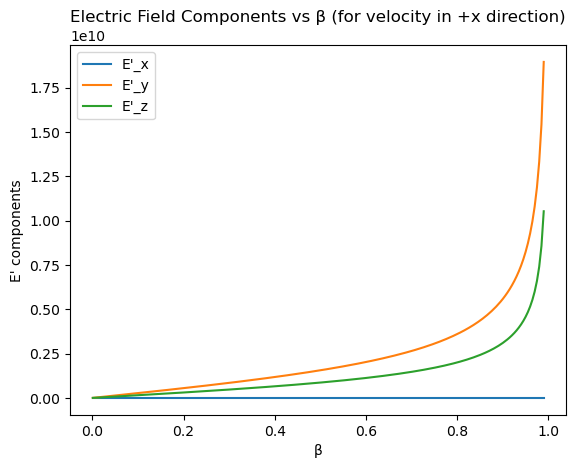

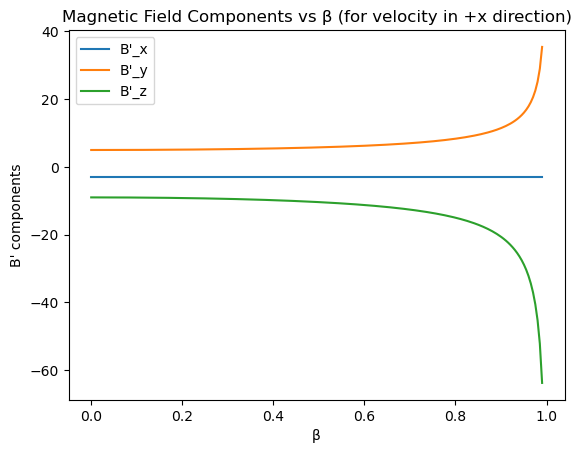

In [3]:
import matplotlib.pyplot as plt

# 1) Component vs. beta plots (skip beta=0)
betas = np.linspace(1e-3, 0.99, 200)
Eps = np.array([E_prime([beta*c, 0, 0], E, B) for beta in betas])
Bps = np.array([B_prime([beta*c, 0, 0], E, B) for beta in betas])

plt.figure()
plt.plot(betas, Eps[:,0], label="E'_x")
plt.plot(betas, Eps[:,1], label="E'_y")
plt.plot(betas, Eps[:,2], label="E'_z")
plt.xlabel("β")
plt.ylabel("E' components")
plt.legend()
plt.title("Electric Field Components vs β (for velocity in +x direction)")
plt.show()

plt.figure()
plt.plot(betas, Bps[:,0], label="B'_x")
plt.plot(betas, Bps[:,1], label="B'_y")
plt.plot(betas, Bps[:,2], label="B'_z")
plt.xlabel("β")
plt.ylabel("B' components")
plt.legend()
plt.title("Magnetic Field Components vs β (for velocity in +x direction)")
plt.show()
